In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive/Landsat9_Exports"

agumbe_rainforest_0_0.tif		 lake_superior_0_0.tif
agumbe_rainforest_0_-1.tif		 lake_superior_0_-1.tif
agumbe_rainforest_0_1.tif		 lake_superior_0_1.tif
agumbe_rainforest_-1_0.tif		 lake_superior_-1_0.tif
agumbe_rainforest_1_0.tif		 lake_superior_1_0.tif
agumbe_rainforest_-1_-1.tif		 lake_superior_-1_-1.tif
agumbe_rainforest_-1_1.tif		 lake_superior_-1_1.tif
agumbe_rainforest_1_-1.tif		 lake_superior_1_-1.tif
agumbe_rainforest_1_1.tif		 lake_superior_1_1.tif
ahmedabad_0_0.tif			 lake_tanganyika_0_0.tif
ahmedabad_0_-1.tif			 lake_tanganyika_0_-1.tif
ahmedabad_0_1.tif			 lake_tanganyika_0_1.tif
ahmedabad_-1_0.tif			 lake_tanganyika_-1_0.tif
ahmedabad_1_0.tif			 lake_tanganyika_1_0.tif
ahmedabad_-1_-1.tif			 lake_tanganyika_-1_-1.tif
ahmedabad_-1_1.tif			 lake_tanganyika_-1_1.tif
ahmedabad_1_-1.tif			 lake_tanganyika_1_-1.tif
ahmedabad_1_1.tif			 lake_tanganyika_1_1.tif
ajanta_caves_0_0.tif			 lake_titicaca_0_0.tif
ajanta_caves_0_-1.tif			 lake_titicaca_0_-1.tif
ajanta_caves_0_1.tif			 lak

In [ ]:
import rasterio

fname = "/content/drive/MyDrive/Landsat9_Exports/agumbe_rainforest_0_0.tif"

with rasterio.open(fname) as src:
    print("Bands:", src.count)
    print("Shape:", src.shape)
    print("Dtypes:", src.dtypes)

Bands: 4
Shape: (1706, 1706)
Dtypes: ('uint16', 'uint16', 'uint16', 'uint16')


In [ ]:
import numpy as np
import rasterio

with rasterio.open(fname) as src:
    data = src.read()

print(data.shape)

(4, 1706, 1706)


In [ ]:
import rasterio
import matplotlib.pyplot as plt

fname = "/content/drive/MyDrive/Landsat9_Exports/agumbe_rainforest_0_0.tif"

with rasterio.open(fname) as src:
    data = src.read()

print(data.shape)

(4, 1706, 1706)


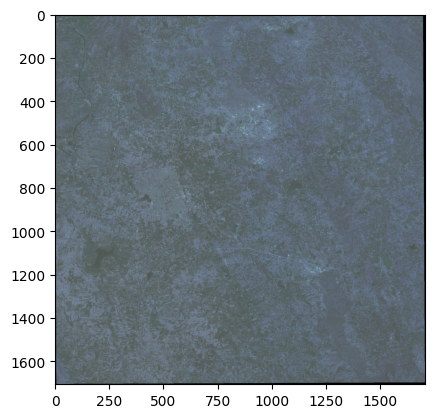

In [ ]:
rgb = data[:3]

rgb = rgb.transpose(1,2,0)

rgb = rgb.astype(float)
rgb /= rgb.max()

plt.imshow(rgb)
plt.show()

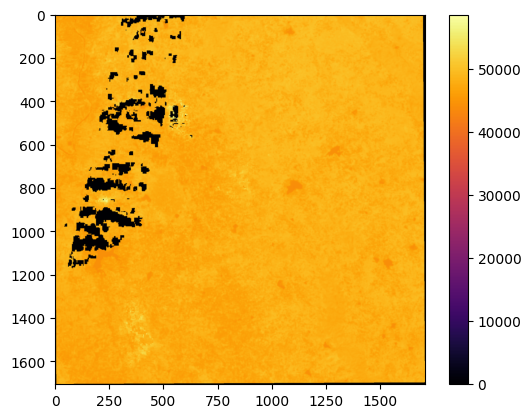

In [ ]:
plt.imshow(data[3], cmap='inferno')
plt.colorbar()
plt.show()

In [ ]:
import numpy as np
import rasterio

fname = "/content/drive/MyDrive/Landsat9_Exports/agumbe_rainforest_0_0.tif"

with rasterio.open(fname) as src:
    data = src.read()

for i in range(4):
    print(
        i,
        data[i].min(),
        data[i].max(),
        data[i].mean()
    )

0 0 19755 8805.809750497863
1 0 22478 10024.810038770824
2 0 24033 10865.58847677805
3 0 58564 46075.71740041698


In [ ]:
import rasterio

fname = "/content/drive/MyDrive/Landsat9_Exports/agumbe_rainforest_0_0.tif"

with rasterio.open(fname) as src:
    print("Descriptions:", src.descriptions)
    print("Tags:", src.tags())

Descriptions: ('SR_B2', 'SR_B3', 'SR_B4', 'ST_B10')
Tags: {'AREA_OR_POINT': 'Area'}


In [ ]:
!cp -r "/content/drive/MyDrive/Landsat9_Exports" /content/

In [ ]:
import rasterio

with rasterio.open(fname) as src:
    print(src.res)

(30.0, 30.0)


In [ ]:
with rasterio.open(fname) as src:
    print(src.res)

(30.0, 30.0)


In [8]:
!git clone https://github.com/jugal-sac/IR-colorization-BAH2026.git

Cloning into 'IR-colorization-BAH2026'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 34 (delta 0), reused 0 (delta 0), pack-reused 33 (from 1)
Receiving objects: 100% (34/34), 2.57 MiB | 45.40 MiB/s, done.


In [3]:
!cd IR-colorization-BAH2026/

In [4]:
ls IR-colorization-BAH2026/

driver.py  output/  README.md  scripts/  utils/


In [ ]:
import rasterio
import os

def split(tif_path, out_dir):

    os.makedirs(out_dir, exist_ok=True)

    with rasterio.open(tif_path) as src:
        data = src.read()

    names = ["_B2","_B3","_B4","_B10"]

    profile = src.profile
    profile.update(count=1)

    for i, n in enumerate(names):
        out_path = os.path.join(out_dir, n + ".tif")

        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(data[i], 1)

In [12]:
!python driver.py

2026-07-04 13:27:18,093 - /content/IR-colorization-BAH2026/output - INFO - Dataset generation finished. Samples available in output/patches


In [6]:
%cd /content/IR-colorization-BAH2026

/content/IR-colorization-BAH2026


In [ ]:
!ls

driver.py		 output      README.md	utils
IR-colorization-BAH2026  output.log  scripts


In [11]:
import os
import rasterio
import glob
import shutil

src_dir = "/content/data"
dst_dir = "/content/IR-colorization-BAH2026/input"

os.makedirs(dst_dir, exist_ok=True)

def split_tif(tif_path, out_folder):

    os.makedirs(out_folder, exist_ok=True)

    with rasterio.open(tif_path) as src:
        data = src.read()

    names = ["B2","B3","B4","B10"]

    profile = src.profile
    profile.update(count=1)

    base = os.path.splitext(os.path.basename(tif_path))[0]

    for i, name in enumerate(names):

        out_path = os.path.join(out_folder, f"{base}_{name}.tif")

        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(data[i], 1)

for tif in glob.glob(src_dir + "/*.tif"):

    product_name = os.path.splitext(os.path.basename(tif))[0]
    out_folder = os.path.join(dst_dir, product_name)

    split_tif(tif, out_folder)

print("Done splitting + organizing input folder")

Done splitting + organizing input folder


In [ ]:
!mkdir -p /content/data
!cp -r /content/drive/MyDrive/Landsat9_Exports/* /content/data/

In [ ]:
import rasterio

path = "/content/data/nairobi_0_0.tif"

with rasterio.open(path) as src:
    print(src.count)
    print(src.shape)

4
(1699, 1698)


In [ ]:
import rasterio
import os

def split_tif(tif_path, out_folder):

    os.makedirs(out_folder, exist_ok=True)

    # IMPORTANT: read everything immediately
    with rasterio.open(tif_path) as src:
        data = src.read()   # load ALL bands into RAM
        profile = src.profile.copy()  # copy immediately

    names = ["B2", "B3", "B4", "B10"]

    profile.update(count=1)

    base = os.path.splitext(os.path.basename(tif_path))[0]

    for i, name in enumerate(names):

        out_path = os.path.join(out_folder, f"{base}_{name}.tif")

        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(data[i], 1)

    print("OK:", tif_path)

In [ ]:
!mkdir -p input

In [ ]:
import rasterio
import os
import numpy as np

def process_file(tif_path):

    print("Processing:", tif_path)

    with rasterio.open(tif_path) as src:

        # FORCE LOAD EVERYTHING FIRST (important fix)
        data = src.read()

        # NOW SAFE (no lazy access anymore)
        profile = src.meta.copy()

    if data.shape[0] != 4:
        print("Skipping (not 4-band):", tif_path)
        return

    names = ["B2", "B3", "B4", "B10"]

    profile.update(count=1)

    base = os.path.splitext(os.path.basename(tif_path))[0]
    out_folder = f"/content/IR-colorization-BAH2026/input/{base}"
    os.makedirs(out_folder, exist_ok=True)

    for i in range(4):

        out_path = os.path.join(out_folder, f"{base}_{names[i]}.tif")

        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(data[i], 1)

    print("OK:", tif_path)

In [10]:
!python driver.py

2026-07-04 13:26:54,281 - /content/IR-colorization-BAH2026/output - ERROR - Input root directory /content/IR-colorization-BAH2026/input not found.


In [ ]:
!find input -type f | head -30

In [ ]:
!find output/patches | head -50

output/patches
output/patches/demo
output/patches/demo/sample_006
output/patches/demo/sample_006/rgb_100m_512.npy
output/patches/demo/sample_006/tir_100m_512.npy
output/patches/demo/sample_006/tir_100m_512.png
output/patches/demo/sample_006/tir_200m.png
output/patches/demo/sample_006/rgb_100m_512.png
output/patches/demo/sample_006/tir_200m.npy


In [13]:
import torch
import numpy as np
import os
from glob import glob

class Pix2PixDataset(torch.utils.data.Dataset):

    def __init__(self, root):
        self.samples = glob(os.path.join(root, "**/tir_100m_512.npy"), recursive=True)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        tir_path = self.samples[idx]
        rgb_path = tir_path.replace("tir_100m_512.npy", "rgb_100m_512.npy")

        tir = np.load(tir_path).astype(np.float32)
        rgb = np.load(rgb_path).astype(np.float32)

        # normalize RGB per band
        for c in range(3):
            rgb[c] = (rgb[c] - rgb[c].min()) / (rgb[c].max() - rgb[c].min() + 1e-8)

        # normalize (important)
        tir = tir / (tir.max() + 1e-6)
        rgb = rgb / 65535.0

        tir = torch.tensor(tir)  # (1,H,W)
        rgb = torch.tensor(rgb)                # (3,H,W)

        rgb = (rgb - rgb.mean()) / (rgb.std() + 1e-8)
        rgb = torch.clamp(rgb, 0, 1)

        print("channel std:", rgb[0].std(), rgb[1].std(), rgb[2].std())

        return tir, rgb

In [14]:
from torch.utils.data import DataLoader

dataset = Pix2PixDataset("/content/IR-colorization-BAH2026/output/patches")

loader = DataLoader(dataset, batch_size=4, shuffle=True)

In [ ]:
x, y = dataset[0]

print(x.shape)  # (1, 512, 512)
print(y.shape)  # (3, 512, 512)

torch.Size([1, 512, 512])
torch.Size([3, 512, 512])


In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import os
import matplotlib.pyplot as plt

In [17]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 4, 2, 1),
                nn.BatchNorm2d(out_c),
                nn.LeakyReLU(0.2)
            )

        self.model = nn.Sequential(
            nn.Conv2d(4, 64, 4, 2, 1),  # TIR(1) + RGB(3)
            nn.LeakyReLU(0.2),

            block(64, 128),
            block(128, 256),
            block(256, 512),

            nn.Conv2d(512, 1, 4, 1, 1)
        )

    def forward(self, x, y):
        return self.model(torch.cat([x, y], dim=1))

In [18]:
bce = nn.BCEWithLogitsLoss()
l1 = nn.L1Loss()

In [19]:
device = "cuda" if torch.cuda.is_available() else "cpu"

G = Generator().to(device)
D = Discriminator().to(device)

opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

In [ ]:
print(x.shape)

torch.Size([1, 1, 512, 512])


In [ ]:
del G
import gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
x, y = next(iter(loader))
print(x.shape, y.shape)

G = Generator().to(device)
fake = G(x.to(device))
print(fake.shape)

torch.Size([1, 1, 512, 512]) torch.Size([1, 3, 512, 512])
torch.Size([1, 3, 512, 512])


In [20]:
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 57.2 MB/s eta 0:00:00


In [21]:
import torch
import torchvision
import torchvision.transforms.functional as TF

from torchmetrics.image import StructuralSimilarityIndexMeasure

# -------------------------
# PSNR
# -------------------------
def psnr(img1, img2, max_val=1.0):
    """
    img1, img2: torch tensors in [0,1], shape (C,H,W)
    """
    mse = torch.mean((img1 - img2) ** 2)
    if mse == 0:
        return 100
    return 20 * torch.log10(max_val / torch.sqrt(mse))


# -------------------------
# SSIM (using torchvision)
# -------------------------

# ✅ Fixed
ssim_fn = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

def ssim(img1, img2):
    return ssim_fn(img1, img2)  # no data_range here

In [22]:
import matplotlib.pyplot as plt

import numpy as np


def show_sample(x, y, fake, step):

    x = x[0].detach().cpu().numpy()
    y = y[0]
    f = fake[0]

    # ---- TIR ----
    if x.ndim == 3:
        x = x[0]

    x = (x - x.min()) / (x.max() + 1e-8)

    # ---- RGB FIX (IMPORTANT PART) ----
    y = np.transpose(y, (1, 2, 0))
    f = np.transpose(f, (1, 2, 0))

    y = np.clip(y, 0, 1)
    f = np.clip(f, 0, 1)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("TIR Input")
    plt.imshow(x, cmap='gray')

    plt.subplot(1,3,2)
    plt.title("Real RGB")
    plt.imshow(y)

    plt.subplot(1,3,3)
    plt.title("Fake RGB")
    plt.imshow(f)

    plt.suptitle(f"Step {step}")
    plt.show()

In [ ]:
rgb = np.transpose(rgb, (1,2,0))
rgb = np.clip(rgb, 0, 1)

In [ ]:
        import matplotlib.pyplot as plt

        def show_debug(x, y):
            plt.subplot(1,2,1)
            plt.imshow(x[0].permute(1,2,0).cpu().numpy())
            plt.title("input x")

            plt.subplot(1,2,2)
            plt.imshow(y[0].permute(1,2,0).cpu().numpy())
            plt.title("target y")

            plt.show()

In [23]:
import os

save_dir = "/content/drive/MyDrive/pix2pix_checkpoints"
os.makedirs(save_dir, exist_ok=True)

In [24]:
import os

save_dir = "/content/drive/MyDrive/pix2pix_results"
os.makedirs(save_dir, exist_ok=True)

In [25]:
import matplotlib.pyplot as plt
import os

def save_epoch_images(tir, real, fake, epoch, save_dir):

    tir = tir[0].detach().cpu().squeeze().numpy()

    real = real[0].detach().cpu().permute(1,2,0).numpy()
    fake = fake[0].detach().cpu().permute(1,2,0).numpy()

    real = real.clip(0,1)
    fake = fake.clip(0,1)

    fig, ax = plt.subplots(1,3, figsize=(15,5))

    ax[0].imshow(tir, cmap='gray')
    ax[0].set_title("Input TIR")
    ax[0].axis("off")

    ax[1].imshow(real)
    ax[1].set_title("Ground Truth RGB")
    ax[1].axis("off")

    ax[2].imshow(fake)
    ax[2].set_title("Generated RGB")
    ax[2].axis("off")

    plt.tight_layout()

    plt.savefig(
        os.path.join(save_dir, f"epoch_{epoch:03d}.png"),
        dpi=200,
        bbox_inches="tight"
    )

    plt.close()

In [27]:
dataset = Pix2PixDataset("/content/IR-colorization-BAH2026/output/patches")
loader = DataLoader(dataset, batch_size=4, shuffle=True)

EPOCHS = 40

for epoch in range(EPOCHS):
    for i, (x, y) in enumerate(loader):

        x, y = x.to(device), y.to(device)

        print("x shape:", x.shape)
        print("y shape:", y.shape)

        print("x min/max:", x.min().item(), x.max().item())
        print("y min/max:", y.min().item(), y.max().item())

        print("TIR unique values:", torch.unique(x).numel())
        print("TIR std:", x.std().item())





        # ---------------------
        # Generator forward
        # ---------------------
        fake = G(x)

        fake_detached = fake.detach().clamp(0, 1)
        real = y.clamp(0, 1)

        # ---------------------
        # Train D
        # ---------------------
        real_pred = D(x, real)
        fake_pred = D(x, fake_detached)

        loss_D = 0.5 * (
            bce(real_pred, torch.ones_like(real_pred)) +
            bce(fake_pred, torch.zeros_like(fake_pred))
        )

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # ---------------------
        # Train G
        # ---------------------
        fake_pred = D(x, fake)

        l1_loss = l1(fake, y)
        gan_loss = bce(fake_pred, torch.ones_like(fake_pred))
        ssim_loss = 1 - ssim(fake_detached, real)

        #loss_G = 1.0* gan_loss + 5 * l1_loss + 5 * (1-ssim_loss)
        loss_G=l1_loss

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        # ---------------------
        # Metrics
        # ---------------------
        psnr_val = psnr(fake_detached, real)
        ssim_val = ssim(fake_detached, real)

        step = epoch * len(loader) + i

        # checkpoint = torch.load(
        #     "/content/drive/MyDrive/pix2pix_checkpoints/pix2pix_epoch_29.pth",
        #     map_location=device
        # )

        # G.load_state_dict(checkpoint['generator_state_dict'])
        # D.load_state_dict(checkpoint['discriminator_state_dict'])

        # opt_G.load_state_dict(checkpoint['optimizer_G_state_dict'])
        # opt_D.load_state_dict(checkpoint['optimizer_D_state_dict'])

        # start_epoch = checkpoint['epoch'] + 1

        if i % 50 == 0:
            fake_vis = fake.detach().cpu().numpy()
            real_vis = y.detach().cpu().numpy()

            # show_sample(x, real_vis, fake_vis, step)
            # print("fake min/max:", fake.min().item(), fake.max().item())

            with torch.no_grad():
              sample_x, sample_y = next(iter(loader))

              sample_x = sample_x.to(device)
              sample_y = sample_y.to(device)

              sample_fake = G(sample_x)

            save_epoch_images(
                sample_x,
                sample_y,
                sample_fake,
                epoch,
                save_dir
            )

            # print(
            #     f"Epoch {epoch} Step {i} | "
            #     f"D: {loss_D.item():.4f} | "
            #     f"G: {loss_G.item():.4f} | "
            #     f"PSNR: {psnr_val.item():.2f} | "
            #     f"SSIM: {ssim_val.item():.3f}"
            # )

            torch.save({
                'epoch': epoch,
                'generator_state_dict': G.state_dict(),
                'discriminator_state_dict': D.state_dict(),
                'optimizer_G_state_dict': opt_G.state_dict(),
                'optimizer_D_state_dict': opt_D.state_dict(),
            }, os.path.join(save_dir, f"pix2pix_epoch_{epoch}.pth"))


channel std: tensor(0.4311) tensor(0.3660) tensor(0.2911)
x shape: torch.Size([1, 1, 512, 512])
y shape: torch.Size([1, 3, 512, 512])
x min/max: 0.8445455431938171 1.0
y min/max: 0.0 1.0
TIR unique values: 3182
TIR std: 0.020740659907460213
channel std: tensor(0.4311) tensor(0.3660) tensor(0.2911)
channel std: tensor(0.4311) tensor(0.3660) tensor(0.2911)
x shape: torch.Size([1, 1, 512, 512])
y shape: torch.Size([1, 3, 512, 512])
x min/max: 0.8445455431938171 1.0
y min/max: 0.0 1.0
TIR unique values: 3182
TIR std: 0.020740659907460213
channel std: tensor(0.4311) tensor(0.3660) tensor(0.2911)
channel std: tensor(0.4311) tensor(0.3660) tensor(0.2911)
x shape: torch.Size([1, 1, 512, 512])
y shape: torch.Size([1, 3, 512, 512])
x min/max: 0.8445455431938171 1.0
y min/max: 0.0 1.0
TIR unique values: 3182
TIR std: 0.020740659907460213
channel std: tensor(0.4311) tensor(0.3660) tensor(0.2911)
channel std: tensor(0.4311) tensor(0.3660) tensor(0.2911)
x shape: torch.Size([1, 1, 512, 512])
y shape

In [ ]:
print("RGB min max:", rgb.min(), rgb.max())
print("RGB shape:", rgb.shape)

RGB min max: 0.0 1.0
RGB shape: (3, 1716, 1715)


In [ ]:
from torchmetrics.functional import structural_similarity_index_measure as ssim_fn

In [ ]:
x1, y1 = next(iter(loader))
x2, y2 = next(iter(loader))

fake1 = G(x1.to(device))
fake2 = G(x2.to(device))

print("difference fake outputs:",
      (fake1 - fake2).abs().mean().item())

difference fake outputs: 7.599524898260768e-10


In [ ]:
total_grad = 0.0
count = 0

for p in G.parameters():
    if p.grad is not None:
        total_grad += p.grad.abs().mean().item()
        count += 1

print("avg grad:", total_grad / max(count, 1))

avg grad: 73.5957832125423


In [ ]:
x1 = x.clone()
x2 = x + 0.1

print((G(x1) - G(x2)).abs().mean())

tensor(6.2296e-05, device='cuda:0', grad_fn=<MeanBackward0>)


In [ ]:
import rasterio
import numpy as np

with rasterio.open(fname) as src:
    img = src.read()

print(img.shape)
print(np.std(img[0]), np.std(img[1]), np.std(img[2]))

(4, 1706, 1706)
1045.2418734705877 1246.6260272223462 1761.6784146250004


In [ ]:
!pip install opencv-python

In [ ]:
import os
import cv2
import numpy as np

patch_root = "/content/IR-colorization-BAH2026/output/patches"
save_root  = "/content/IR-colorization-BAH2026/output/lanczos_sr"

os.makedirs(save_root, exist_ok=True)

samples = sorted(os.listdir(patch_root))

print("Total samples:", len(samples))

for sample in samples:

    sample_path = os.path.join(patch_root, sample)

    tir_path = os.path.join(sample_path, "tir_200m.npy")

    if not os.path.exists(tir_path):
        continue

    tir = np.load(tir_path)

    # Remove channel dimension if present
    if tir.ndim == 3:
        tir = tir[0]

    H, W = tir.shape

    # 200m -> 100m
    tir_sr = cv2.resize(
        tir,
        (W*2, H*2),
        interpolation=cv2.INTER_LANCZOS4
    )

    out_dir = os.path.join(save_root, sample)
    os.makedirs(out_dir, exist_ok=True)

    np.save(
        os.path.join(out_dir, "tir_100m_lanczos.npy"),
        tir_sr.astype(np.float32)
    )

print("Finished.")

Total samples: 1
Finished.


In [ ]:
import matplotlib.pyplot as plt

for sample in samples:

    path = os.path.join(save_root, sample)

    npy = os.path.join(path,"tir_100m_lanczos.npy")

    if not os.path.exists(npy):
        continue

    img = np.load(npy)

    plt.imsave(
        os.path.join(path,"tir_100m_lanczos.png"),
        img,
        cmap='gray'
    )

In [16]:
import torch
import torch.nn as nn

class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.e1 = nn.Sequential(
            nn.Conv2d(1,64,4,2,1),
            nn.LeakyReLU(0.2)
        )

        self.e2 = nn.Sequential(
            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2)
        )

        self.e3 = nn.Sequential(
            nn.Conv2d(128,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2)
        )

        self.e4 = nn.Sequential(
            nn.Conv2d(256,512,4,2,1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2)
        )

        # Decoder
        self.d1 = nn.Sequential(
            nn.ConvTranspose2d(512,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )

        self.d2 = nn.Sequential(
            nn.ConvTranspose2d(512,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.d3 = nn.Sequential(
            nn.ConvTranspose2d(256,64,4,2,1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.d4 = nn.ConvTranspose2d(128,3,4,2,1)

        self.out = nn.Sigmoid()

    def forward(self,x):

        e1 = self.e1(x)      # 256
        e2 = self.e2(e1)     # 128
        e3 = self.e3(e2)     # 64
        e4 = self.e4(e3)     # 32

        d1 = self.d1(e4)

        d1 = torch.cat([d1,e3],dim=1)

        d2 = self.d2(d1)

        d2 = torch.cat([d2,e2],dim=1)

        d3 = self.d3(d2)

        d3 = torch.cat([d3,e1],dim=1)

        d4 = self.d4(d3)

        return self.out(d4)

In [ ]:
import torch
import numpy as np
import os
from glob import glob

class Pix2PixDataset(torch.utils.data.Dataset):

    def __init__(self, patch_root, lanczos_root):

        self.patch_root = patch_root
        self.lanczos_root = lanczos_root

        # All RGB files
        self.rgb_files = sorted(
            glob(os.path.join(patch_root, "**", "rgb_100m_512.npy"), recursive=True)
        )

    def __len__(self):
        return len(self.rgb_files)

    def __getitem__(self, idx):

        rgb_path = self.rgb_files[idx]

        # sample_001
        sample_name = os.path.basename(os.path.dirname(rgb_path))

        tir_path = os.path.join(
            self.lanczos_root,
            sample_name,
            "tir_100m_lanczos.npy"
        )

        rgb = np.load(rgb_path).astype(np.float32)
        tir = np.load(tir_path).astype(np.float32)

        # -----------------------------
        # Normalize TIR
        # -----------------------------
        tir = (tir - tir.min()) / (tir.max() - tir.min() + 1e-8)

        # -----------------------------
        # Normalize RGB
        # -----------------------------
        for c in range(3):
            rgb[c] = (rgb[c] - rgb[c].min()) / (rgb[c].max() - rgb[c].min() + 1e-8)

        # Convert to tensors
        tir = torch.from_numpy(tir).unsqueeze(0)
        rgb = torch.from_numpy(rgb)

        return tir, rgb

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving swinir_model_epoch_13.pth to swinir_model_epoch_13.pth


In [ ]:
!unzip -q swinir_model_epoch_13.pth.zip

In [ ]:
import os

print(os.listdir())

['README.md', 'swinir_model_epoch_13', 'input', 'output', 'driver.py', '.git', 'utils', 'output.log', 'scripts', 'swinir_model_epoch_13.pth.zip', 'IR-colorization-BAH2026']


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'output', 'IR-colorization-BAH2026', 'drive', 'sample_data']


In [ ]:
!find /content -name "*.pth"

/content/IR-colorization-BAH2026/swinir_model_epoch_13.pth
find: ‘/content/drive/MyDrive/galaxy_zoo/images_test_rev1/images_test_rev1’: Input/output error
find: ‘/content/drive/MyDrive/galaxy_zoo/images_training_rev1/images_training_rev1’: Input/output error
/content/drive/MyDrive/best_zoobot_model.pth
/content/drive/MyDrive/best_zoobot_model_edge_nonedge.pth


In [ ]:
import torch

ckpt = torch.load("/content/IR-colorization-BAH2026/swinir_model_epoch_13.pth", map_location="cpu")

print(type(ckpt))

if isinstance(ckpt, dict):
    print("Keys:")
    print(ckpt.keys())

<class 'collections.OrderedDict'>
Keys:
odict_keys(['swinir.conv_first.weight', 'swinir.conv_first.bias', 'swinir.patch_embed.norm.weight', 'swinir.patch_embed.norm.bias', 'swinir.layers.0.residual_group.blocks.0.norm1.weight', 'swinir.layers.0.residual_group.blocks.0.norm1.bias', 'swinir.layers.0.residual_group.blocks.0.attn.relative_position_bias_table', 'swinir.layers.0.residual_group.blocks.0.attn.relative_position_index', 'swinir.layers.0.residual_group.blocks.0.attn.qkv.weight', 'swinir.layers.0.residual_group.blocks.0.attn.qkv.bias', 'swinir.layers.0.residual_group.blocks.0.attn.proj.weight', 'swinir.layers.0.residual_group.blocks.0.attn.proj.bias', 'swinir.layers.0.residual_group.blocks.0.norm2.weight', 'swinir.layers.0.residual_group.blocks.0.norm2.bias', 'swinir.layers.0.residual_group.blocks.0.mlp.fc1.weight', 'swinir.layers.0.residual_group.blocks.0.mlp.fc1.bias', 'swinir.layers.0.residual_group.blocks.0.mlp.fc2.weight', 'swinir.layers.0.residual_group.blocks.0.mlp.fc2.bias

In [ ]:
!git clone https://github.com/JingyunLiang/SwinIR.git
%cd SwinIR

Cloning into 'SwinIR'...
remote: Enumerating objects: 333, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 333 (delta 6), reused 2 (delta 2), pack-reused 323 (from 2)
Receiving objects: 100% (333/333), 29.84 MiB | 18.41 MiB/s, done.
Resolving deltas: 100% (119/119), done.
/content/IR-colorization-BAH2026/SwinIR


In [ ]:
from models.network_swinir import SwinIR

In [ ]:
model = SwinIR(
    upscale=2,
    in_chans=3,
    img_size=64,
    window_size=8,
    img_range=1.0,
    depths=[6,6,6,6],
    embed_dim=60,        # CRITICAL
    num_heads=[6,6,6,6],
    mlp_ratio=2,
    upsampler='pixelshuffle',
    resi_connection='1conv'
)

In [ ]:
ckpt = torch.load("/content/IR-colorization-BAH2026/swinir_model_epoch_13.pth", map_location="cpu")

# extract weights safely
if "params" in ckpt:
    state_dict = ckpt["params"]
elif "state_dict" in ckpt:
    state_dict = ckpt["state_dict"]
else:
    state_dict = ckpt

# remove prefix if needed
new_state_dict = {}
for k, v in state_dict.items():
    k = k.replace("swinir.", "")
    new_state_dict[k] = v

model.load_state_dict(new_state_dict, strict=True)

model = model.cuda()
model.eval()

RuntimeError: Error(s) in loading state_dict for SwinIR:
	Missing key(s) in state_dict: "conv_before_upsample.0.weight", "conv_before_upsample.0.bias", "conv_last.weight", "conv_last.bias". 
	size mismatch for upsample.0.weight: copying a param with shape torch.Size([12, 60, 3, 3]) from checkpoint, the shape in current model is torch.Size([256, 64, 3, 3]).
	size mismatch for upsample.0.bias: copying a param with shape torch.Size([12]) from checkpoint, the shape in current model is torch.Size([256]).

In [ ]:
import torch

ckpt = torch.load("/content/IR-colorization-BAH2026/swinir_model_epoch_13.pth", map_location="cpu")

state_dict = ckpt
if "params" in ckpt:
    state_dict = ckpt["params"]
elif "state_dict" in ckpt:
    state_dict = ckpt["state_dict"]

In [ ]:
for k, v in state_dict.items():
    if "conv_first" in k:
        print(k, v.shape)

    if "upsample" in k:
        print(k, v.shape)

swinir.conv_first.weight torch.Size([60, 3, 3, 3])
swinir.conv_first.bias torch.Size([60])
swinir.upsample.0.weight torch.Size([12, 60, 3, 3])
swinir.upsample.0.bias torch.Size([12])


In [ ]:
model.load_state_dict(state_dict, strict=False)

_IncompatibleKeys(missing_keys=['conv_first.weight', 'conv_first.bias', 'patch_embed.norm.weight', 'patch_embed.norm.bias', 'layers.0.residual_group.blocks.0.norm1.weight', 'layers.0.residual_group.blocks.0.norm1.bias', 'layers.0.residual_group.blocks.0.attn.relative_position_bias_table', 'layers.0.residual_group.blocks.0.attn.relative_position_index', 'layers.0.residual_group.blocks.0.attn.qkv.weight', 'layers.0.residual_group.blocks.0.attn.qkv.bias', 'layers.0.residual_group.blocks.0.attn.proj.weight', 'layers.0.residual_group.blocks.0.attn.proj.bias', 'layers.0.residual_group.blocks.0.norm2.weight', 'layers.0.residual_group.blocks.0.norm2.bias', 'layers.0.residual_group.blocks.0.mlp.fc1.weight', 'layers.0.residual_group.blocks.0.mlp.fc1.bias', 'layers.0.residual_group.blocks.0.mlp.fc2.weight', 'layers.0.residual_group.blocks.0.mlp.fc2.bias', 'layers.0.residual_group.blocks.1.attn_mask', 'layers.0.residual_group.blocks.1.norm1.weight', 'layers.0.residual_group.blocks.1.norm1.bias', '

In [ ]:
with torch.no_grad():
    y = model(x)
print(y.shape)

torch.Size([1, 3, 1024, 1024])


In [ ]:
import matplotlib.pyplot as plt

img = out[0].detach().cpu().permute(1,2,0)

print(img.min().item(), img.max().item(), img.mean().item())

plt.imshow(img.clamp(0,1))
plt.title("SwinIR Output")
plt.show()

NameError: name 'out' is not defined

In [ ]:
x, _ = next(iter(loader))
x = x.to(device)

model.eval()
with torch.no_grad():
    out = torch.sigmoid(model(x))

print(out.shape)

channel std: tensor(0.4311) tensor(0.3660) tensor(0.2911)
torch.Size([1, 3, 1024, 1024])


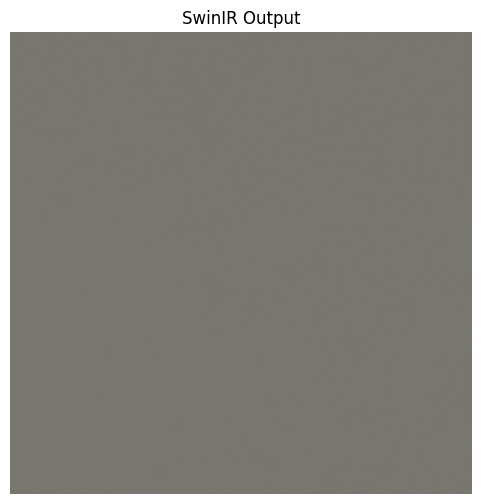

In [ ]:
import matplotlib.pyplot as plt

img = out[0].detach().cpu()

# IMPORTANT: clamp first
img = img.clamp(0, 1)

img = img.permute(1,2,0)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("SwinIR Output")
plt.axis("off")
plt.show()

In [ ]:
print("INPUT STATS")
print("min:", x.min().item())
print("max:", x.max().item())
print("mean:", x.mean().item())
print("std:", x.std().item())

INPUT STATS
min: 0.8445455431938171
max: 1.0
mean: 0.9146985411643982
std: 0.020740659907460213


In [ ]:
x = x.float()

# force full dynamic range
x = (x - x.min()) / (x.max() - x.min() + 1e-8)

# expand to 3 channels (IMPORTANT for SwinIR)
x = x.repeat(1, 3, 1, 1)

In [ ]:
with torch.no_grad():
    out = model(x)

print(out.min(), out.max(), out.std())

tensor(0.3937) tensor(0.5185) tensor(0.0212)


In [ ]:
with torch.no_grad():
    out_raw = model(x)

print("OUTPUT RAW")
print("min:", out_raw.min().item())
print("max:", out_raw.max().item())
print("mean:", out_raw.mean().item())
print("std:", out_raw.std().item())

OUTPUT RAW
min: 0.3915261924266815
max: 0.5122792720794678
mean: 0.4596136510372162
std: 0.026361975818872452


In [ ]:
print("input std:", x.std().item())

out = model(x)

print("output std:", out.std().item())
print("output mean:", out.mean().item())

input std: 0.13341936469078064


In [ ]:
loader = DataLoader(dataset, batch_size=4, shuffle=True)
x, _ = next(iter(loader))
x = x.to(device)
x = x.float()

# ImageNet-style normalization (CRITICAL)
mean = x.mean()
std = x.std() + 1e-8

x = (x - mean) / std

NameError: name 'DataLoader' is not defined

In [ ]:
import torch
import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

deeplab = torchvision.models.segmentation.deeplabv3_resnet101(
    weights=torchvision.models.segmentation.DeepLabV3_ResNet101_Weights.DEFAULT
)

deeplab.eval()
deeplab.to(device)

for p in deeplab.parameters():
    p.requires_grad = False

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:02<00:00, 83.6MB/s]
